<a href="https://colab.research.google.com/github/crd10lop/ml-crop-recommendation/blob/main/01_EDA_Recomendacion_Cultivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO: Sistema predictivo de recomendación de cultivos
## PRIMERA ENTREGA: Análisis Exploratorio de Datos (EDA)

* El objetivo de esta etapa es realizar un análisis exploratorio de los datos que permita comprender la composición de la base de datos.
* La base de datos contiene información sobre los niveles de nitrógeno, fósforo, potasio, temperatura, humedad, pH y lluvia[cite: 1].
* A partir de estas siete variables de entrada numéricas, se busca clasificar y recomendar el cultivo adecuado entre 22 alternativas posibles[cite: 1].

In [ ]:
# Conectar Google Colab con tu Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:

# ------------------------------------------------------------------------------
# 1. Carga del conjunto de datos desde Drive
# ------------------------------------------------------------------------------
print("--- 1. CARGA DE DATOS ---")
# Ruta exacta de Google Drive montado en Colab
ruta_archivo = '/content/drive/MyDrive/ESTUDIO/UDEA/MODELOS IA 2/PROYECTO DEL CURSO/Crop_recommendation.csv'

try:
    df = pd.read_csv(ruta_archivo)
    print("Datos cargados exitosamente desde Drive.\n")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta:\n{ruta_archivo}\nVerifica que el nombre sea exactamente 'Crop_recommendation.csv' y esté en la carpeta correcta.\n")

--- 1. CARGA DE DATOS ---
Datos cargados exitosamente desde Drive.



In [ ]:

# ------------------------------------------------------------------------------
# 2. Descripción de la composición de la base de datos (Sección 2 de la guía)
# ------------------------------------------------------------------------------
print("--- 2. COMPOSICIÓN DE LA BASE DE DATOS ---")

# Número de muestras y variables
num_muestras, num_variables = df.shape
print(f"Número total de muestras (registros): {num_muestras}")
print(f"Número total de variables (columnas): {num_variables}\n")

# Significado y tipos de variables (codificación)
print("Tipos de datos por variable:")
display(df.dtypes)
print("\nNota: Todas las variables de entrada son numéricas (int64 o float64).")
print("La variable objetivo 'label' es categórica (object/string) y será codificada más adelante para el modelado.\n")


--- 2. COMPOSICIÓN DE LA BASE DE DATOS ---
Número total de muestras (registros): 2200
Número total de variables (columnas): 10

Tipos de datos por variable:


,0
Nitrogen,int64
phosphorus,int64
potassium,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object
Unnamed: 8,float64
Unnamed: 9,float64



Nota: Todas las variables de entrada son numéricas (int64 o float64).
La variable objetivo 'label' es categórica (object/string) y será codificada más adelante para el modelado.



In [ ]:

# ------------------------------------------------------------------------------
# 3. Revisión de datos faltantes y duplicados
# ------------------------------------------------------------------------------
print("--- 3. REVISIÓN DE DATOS FALTANTES Y DUPLICADOS ---")

# Datos faltantes
faltantes = df.isnull().sum()
print("Cantidad de datos faltantes por variable:")
display(faltantes)
if faltantes.sum() == 0:
    print("-> Estrategia de imputación: No es necesaria, no hay datos faltantes en el dataset.\n")
else:
    print("-> Se requiere estrategia de imputación.\n")

# Registros duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")
if duplicados == 0:
     print("-> No se encontraron registros duplicados.\n")
else:
    print("-> Eliminando registros duplicados...")
    df = df.drop_duplicates()
    print(f"Nuevo tamaño del dataset: {df.shape}\n")

--- 3. REVISIÓN DE DATOS FALTANTES Y DUPLICADOS ---
Cantidad de datos faltantes por variable:


,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0
Unnamed: 8,2200
Unnamed: 9,2200


-> Se requiere estrategia de imputación.

Número de registros duplicados: 0
-> No se encontraron registros duplicados.



--- 4. ANÁLISIS EXPLORATORIO INICIAL ---
Estadísticas descriptivas de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Nitrogen,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
phosphorus,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
potassium,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
Unnamed: 8,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Distribución de las clases (Cultivos recomendados):


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


/tmp/ipykernel_7532/4193543967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)


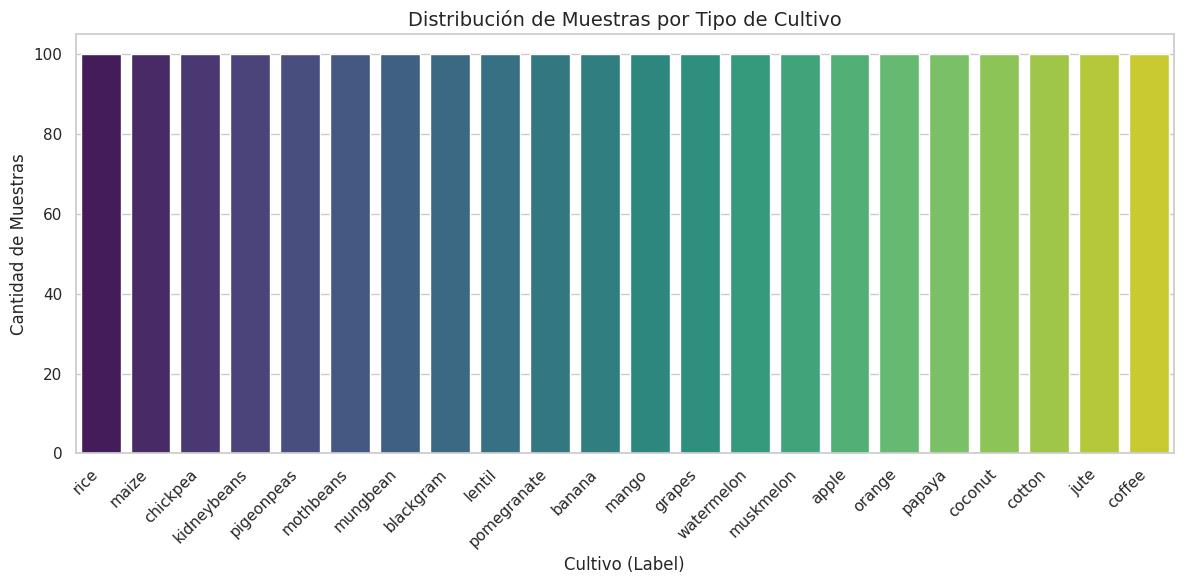

In [ ]:

# ------------------------------------------------------------------------------
# 4. Análisis Exploratorio: Estadísticas y Distribución de Clases
# ------------------------------------------------------------------------------
print("--- 4. ANÁLISIS EXPLORATORIO INICIAL ---")

print("Estadísticas descriptivas de las variables numéricas:")
display(df.describe().T)

print("\nDistribución de las clases (Cultivos recomendados):")
distribucion_clases = df['label'].value_counts()
display(distribucion_clases)

# Gráfico de distribución de clases para verificar balanceo
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)
plt.title('Distribución de Muestras por Tipo de Cultivo', fontsize=14)
plt.xlabel('Cultivo (Label)', fontsize=12)
plt.ylabel('Cantidad de Muestras', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:

# ------------------------------------------------------------------------------
# 5. Separación preliminar de variables
# ------------------------------------------------------------------------------
# Separamos las características (X) de la variable objetivo (y)
X = df.drop('label', axis=1)
y = df['label']
print("\nLas variables predictoras (X) y el objetivo (y) han sido separados exitosamente.")


Las variables predictoras (X) y el objetivo (y) han sido separados exitosamente.
